In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('/home/lucky/Machine_Learning/datasets/train.csv',usecols=['Age','Fare','Survived'])

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [8]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [11]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


In [10]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [15]:
missing = X_test['Age_imputed'].isnull().sum()

random_sample = X_test['Age'].dropna().sample(
    missing,
    random_state=42
).values

X_test.loc[missing, 'Age_imputed'] = random_sample

In [21]:
missing_mask = X_train["Age_imputed"].isnull()
random_sample = X_train["Age"].dropna().sample(
    missing_mask.sum(),
    random_state=42
).values

X_train.loc[missing_mask, "Age_imputed"] = random_sample

In [22]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,70.5
493,71.0,49.5042,71.0
527,NaN,221.7792,48.0


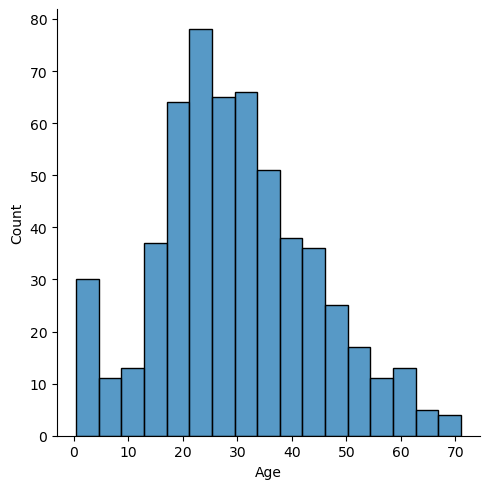

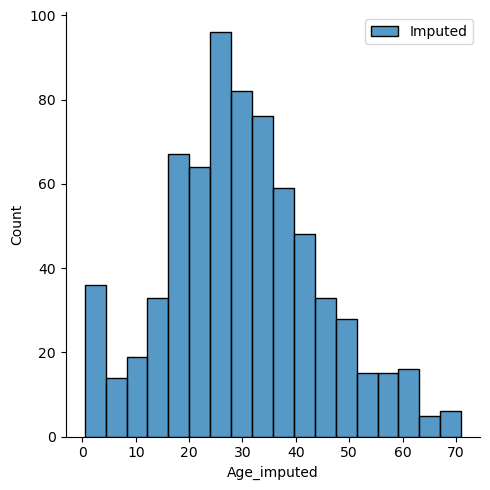

In [25]:
sns.displot(X_train['Age'],label='Original')
sns.displot(X_train['Age_imputed'],label='Imputed')

plt.legend()
plt.show()

In [26]:
print('Original Variable variance:',X_train['Age'].var())
print("Variance after imputation:",X_train['Age_imputed'].var())

Original Variable variance: 204.3495133904614
Variance after imputation: 205.2552731111426


In [27]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,58.077835
Age,71.512440,204.349513,204.349513
Age_imputed,58.077835,204.349513,205.255273


<Axes: >

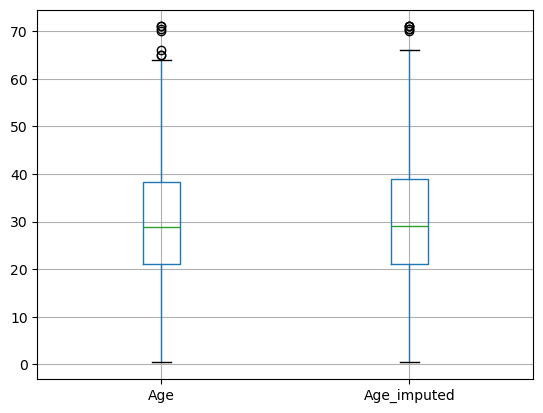

In [28]:
X_train[['Age','Age_imputed']].boxplot()